In [6]:
import sys
!{sys.executable} -m pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

In [2]:
import mysql.connector

In [7]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="mari@123",
    database="ecommerce_analysis"
)
print("Connected Successfully")

Connected Successfully


# Monthly Revenue KPI

query = """
SELECT
    MONTH(o.order_purchase_timestamp) AS month,
    ROUND(SUM(oi.price),2) AS monthly_revenue
FROM orders o
JOIN order_items oi
ON o.order_id = oi.order_id
GROUP BY month
ORDER BY month;
"""

monthly_revenue = pd.read_sql(query, conn)

monthly_revenue

# Monthly Revenue Trend Chart

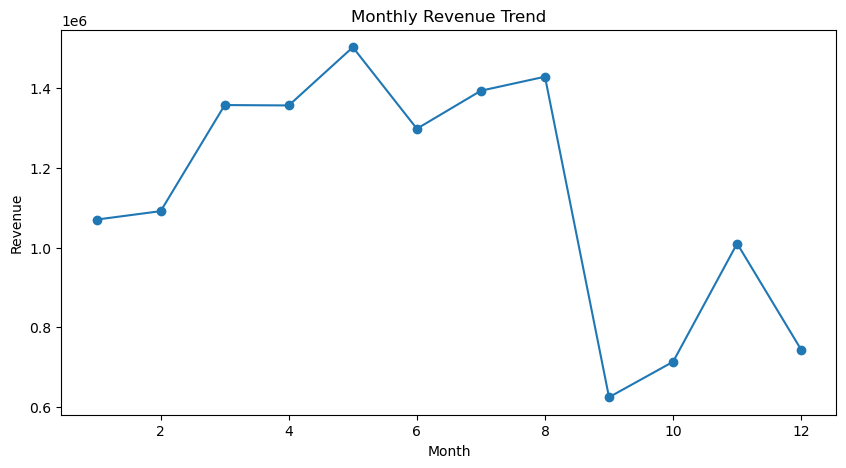

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue['month'],
    monthly_revenue['monthly_revenue'],
    marker='o'
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.savefig("../charts/monthly_revenue_trend.png")

plt.show()

# Order Status Analysis

In [10]:
query2 = """

SELECT
    order_status,
    COUNT(*) AS total_orders
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC;
"""

order_status = pd.read_sql(query2, conn)

order_status

C:\Users\gayat\AppData\Local\Temp\ipykernel_12084\4156872419.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_status = pd.read_sql(query2, conn)


,order_status,total_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


# Order Status Chart

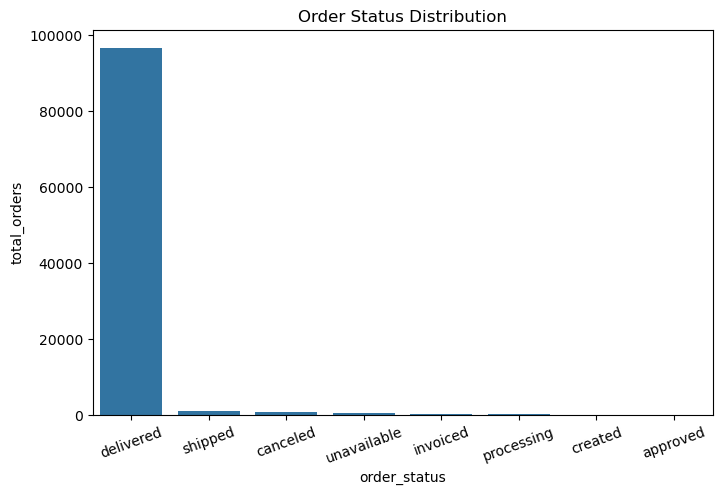

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='order_status',
    y='total_orders',
    data=order_status
)

plt.title("Order Status Distribution")

plt.xticks(rotation=20)

plt.savefig("../charts/order_status_distribution.png")

plt.show()

# Top Products Analysis

In [12]:
query3 = """

SELECT
    product_id,
    ROUND(SUM(price),2) AS revenue
FROM order_items
GROUP BY product_id
ORDER BY revenue DESC
LIMIT 10;
"""

top_products = pd.read_sql(query3, conn)

top_products

C:\Users\gayat\AppData\Local\Temp\ipykernel_12084\362732774.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_products = pd.read_sql(query3, conn)


,product_id,revenue
0,bb50f2e236e5eea0100680137654686c,63885.00
1,6cdd53843498f92890544667809f1595,54730.20
2,d6160fb7873f184099d9bc95e30376af,48899.34
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51
4,99a4788cb24856965c36a24e339b6058,43025.56
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60
6,25c38557cf793876c5abdd5931f922db,38907.32
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90
8,53b36df67ebb7c41585e8d54d6772e08,37683.42
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90


# Top Products Chart

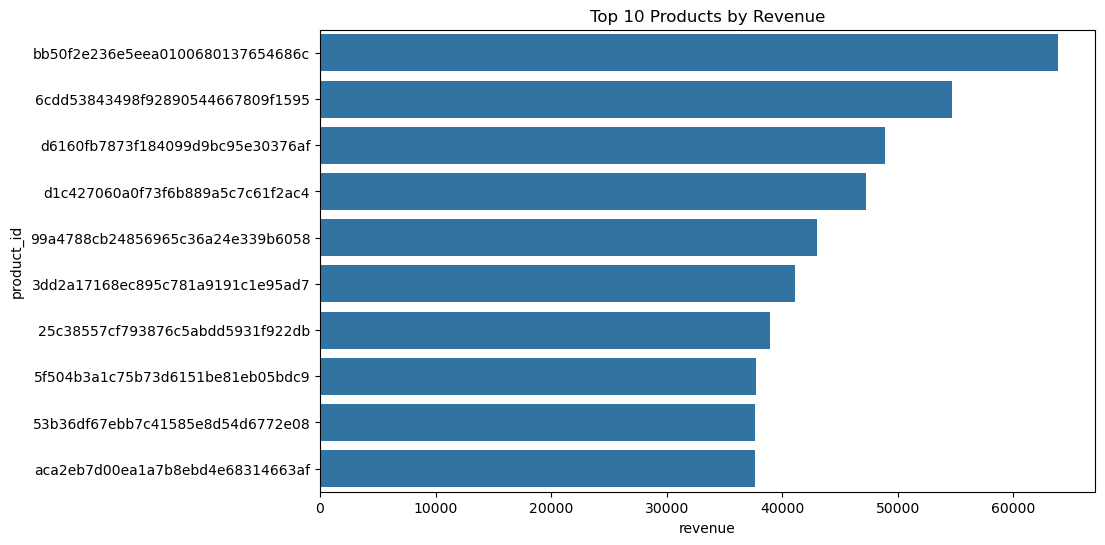

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='revenue',
    y='product_id',
    data=top_products
)

plt.title("Top 10 Products by Revenue")

plt.savefig("../charts/top_products_revenue.png")

plt.show()

# Monthly Orders Trend

In [14]:
query4 = """

SELECT
    MONTH(order_purchase_timestamp) AS month,
    COUNT(order_id) AS total_orders
FROM orders
GROUP BY month
ORDER BY month;
"""

monthly_orders = pd.read_sql(query4, conn)
monthly_orders

C:\Users\gayat\AppData\Local\Temp\ipykernel_12084\1910194372.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_orders = pd.read_sql(query4, conn)


,month,total_orders
0,1,8069
1,2,8508
2,3,9893
3,4,9343
4,5,10573
5,6,9412
6,7,10318
7,8,10843
8,9,4305
9,10,4959


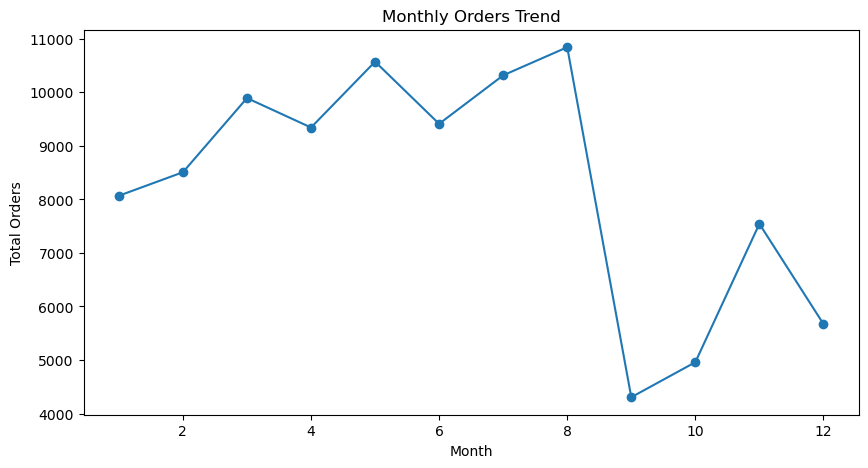

In [15]:
plt.figure(figsize=(10,5))
plt.plot(monthly_orders['month'], monthly_orders['total_orders'], marker='o')
plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.savefig("../charts/monthly_orders_trend.png")
plt.show()

# Top Customers by Orders

In [16]:
query5 = """

SELECT
    customer_id,
    COUNT(order_id) AS total_orders
FROM orders
GROUP BY customer_id
ORDER BY total_orders DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query5, conn)
top_customers

C:\Users\gayat\AppData\Local\Temp\ipykernel_12084\673505569.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  top_customers = pd.read_sql(query5, conn)


,customer_id,total_orders
0,e04757bb7741d0781cda14c9be20ad2a,1
1,96c3d51816ee07cb78ebbfe0e8bdb889,1
2,f1913159750548eb81dca4b69fbd5e0c,1
3,6967af003c642a30a79242f2756a73d5,1
4,5eef8c5a24bd948fac341c6ebe3ce41e,1
5,2dc86eb45d955da9a9afa6f431ac00f4,1
6,92f1d4d2f1a2a03f858f7afea11ff0b9,1
7,03ee2343040a3871cb2cf313cc795c72,1
8,9573415dd691e34a2b92c9e39558ef22,1
9,bc64988c743d4ea05faa42f945a49396,1


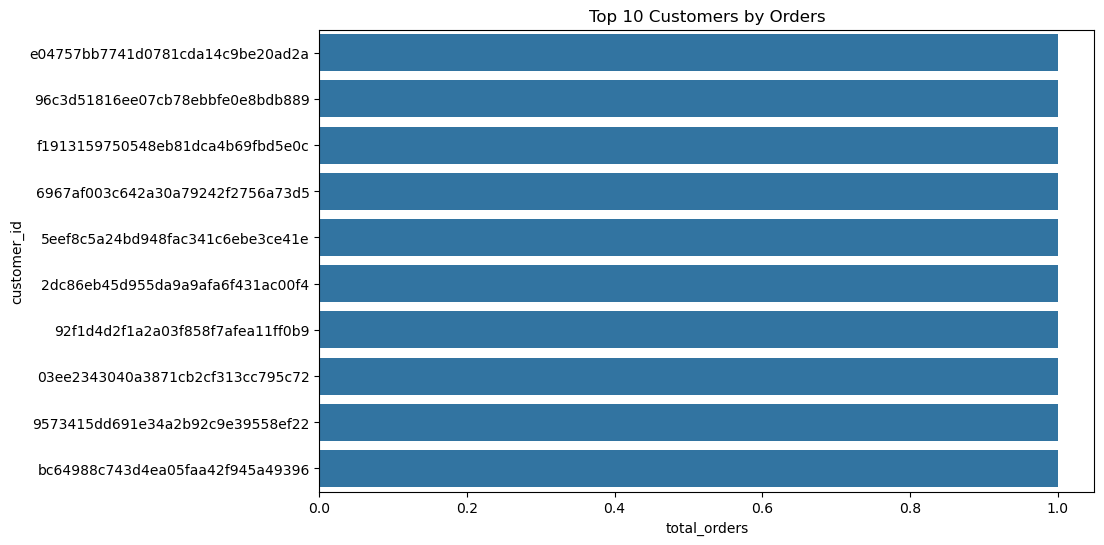

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x='total_orders', y='customer_id', data=top_customers)
plt.title("Top 10 Customers by Orders")
plt.savefig("../charts/top_customers_orders.png")
plt.show()

# Revenue by Product Category

In [18]:
query6 = """

SELECT
    p.product_category_name,
    ROUND(SUM(oi.price),2) AS revenue
FROM order_items oi
JOIN products p
ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY revenue DESC
LIMIT 10;
"""

category_revenue = pd.read_sql(query6, conn)
category_revenue

C:\Users\gayat\AppData\Local\Temp\ipykernel_12084\2569272439.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  category_revenue = pd.read_sql(query6, conn)


,product_category_name,revenue
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


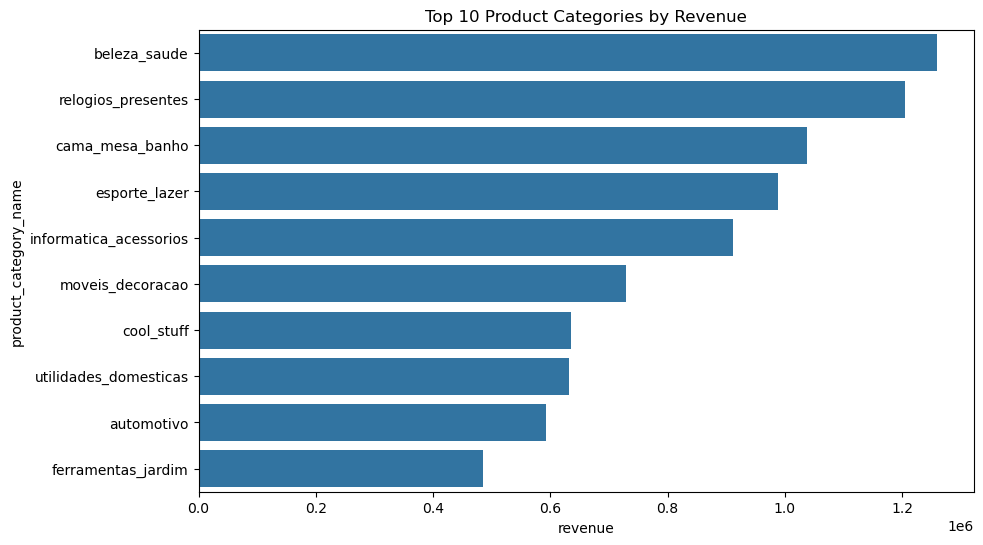

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(x='revenue', y='product_category_name', data=category_revenue)
plt.title("Top 10 Product Categories by Revenue")
plt.savefig("../charts/category_revenue.png")
plt.show()

# Average Price by Product Category

In [24]:
query7 = """
SELECT
    p.product_category_name,
    ROUND(AVG(oi.price),2) AS avg_price
FROM order_items oi
JOIN products p
ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY avg_price DESC
LIMIT 10;
"""

avg_category_price = pd.read_sql(query7, conn)
avg_category_price

C:\Users\gayat\AppData\Local\Temp\ipykernel_12084\1556500182.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  avg_category_price = pd.read_sql(query7, conn)


,product_category_name,avg_price
0,pcs,1098.34
1,portateis_casa_forno_e_cafe,624.29
2,eletrodomesticos_2,476.12
3,agro_industria_e_comercio,342.12
4,instrumentos_musicais,281.62
5,eletroportateis,280.78
6,portateis_cozinha_e_preparadores_de_alimentos,264.57
7,telefonia_fixa,225.69
8,construcao_ferramentas_seguranca,208.99
9,relogios_presentes,201.14


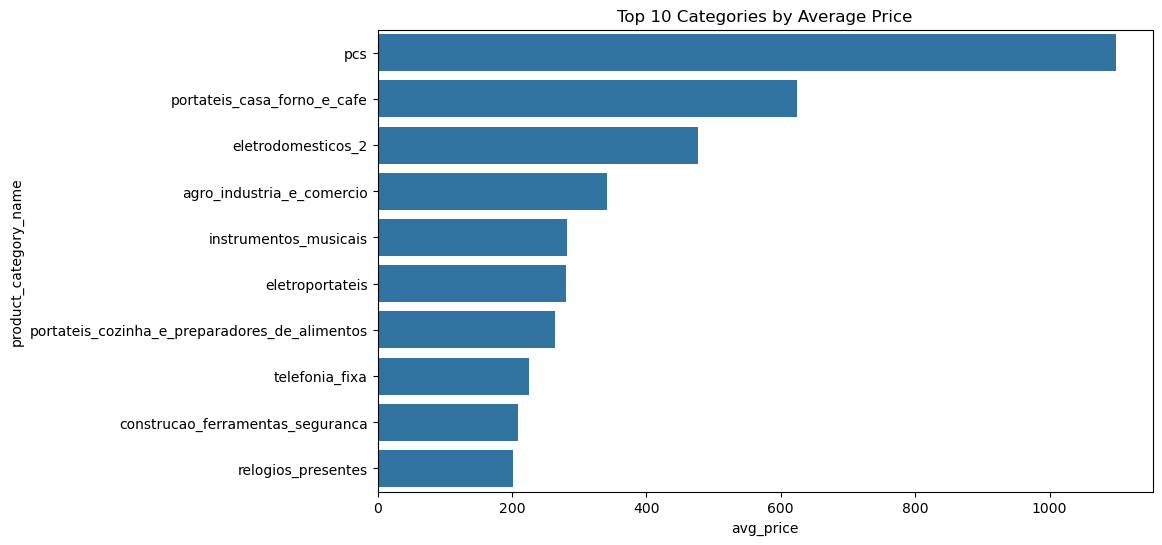

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(x='avg_price', y='product_category_name', data=avg_category_price)
plt.title("Top 10 Categories by Average Price")
plt.savefig("../charts/avg_category_price.png")
plt.show()